## 1. Importation des bibliothèques

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from keras import models, layers, regularizers

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 2. Paramètres




In [ ]:
NB_WORDS = 10000
NB_START_EPOCHS = 20
BATCH_SIZE = 512
MAX_LEN = 20


## 3. Lecture du fichier CSV

In [ ]:
df = pd.read_csv("/content/sample_data/Tweets.csv")
df.head()


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 4. Garder les colonnes utiles

In [ ]:
df = df[['text', 'airline_sentiment']]
df.head()


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


## 5. Fonctions de nettoyage

In [ ]:
def remove_stopwords(input_text):

    stopwords_list = stopwords.words('english')

    whitelist = ["n't", "not", "no"]

    words = input_text.split()

    clean_words = [
        word for word in words
        if (word not in stopwords_list or word in whitelist)
        and len(word) > 1
    ]

    return " ".join(clean_words)


def remove_mentions(input_text):

    return re.sub(r'@\w+', '', input_text)


## 6. Nettoyage des données

In [ ]:
df.text = df.text.apply(remove_stopwords).apply(remove_mentions)

df.head()


,text,airline_sentiment
0,What said.,neutral
1,plus added commercials experience... tacky.,positive
2,today... Must mean need take another trip!,neutral
3,"really aggressive blast obnoxious ""entertainm...",negative
4,really big bad thing,negative


## 7. Séparation des données

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df.text,
    df.airline_sentiment,
    test_size=0.1,
    random_state=42
)

print('Données apprentissage :', X_train.shape[0])
print('Données test :', X_test.shape[0])


Données apprentissage : 13176
Données test : 1464


## 8. surapprentissage

In [ ]:
tk = Tokenizer(
    num_words=NB_WORDS,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    char_level=False,
    split=' '
)

tk.fit_on_texts(X_train)

print('Documents :', tk.document_count)
print('Nombre de mots :', tk.num_words)


Documents : 13176
Nombre de mots : 10000


## 9. Transformation des textes

In [ ]:
X_train_oh = tk.texts_to_matrix(X_train, mode='binary')
X_test_oh = tk.texts_to_matrix(X_test, mode='binary')


## 10. Encodage des classes

In [ ]:
le = LabelEncoder()

y_train_le = le.fit_transform(y_train)
y_test_le = le.fit_transform(y_test)

y_train_oh = to_categorical(y_train_le)
y_test_oh = to_categorical(y_test_le)

print(y_train.iloc[0], '->', y_train_le[0])


negative -> 0


## 11. Création des données de validation

In [ ]:
X_train_rest, X_valid, y_train_rest, y_valid = train_test_split(
    X_train_oh,
    y_train_oh,
    test_size=0.1,
    random_state=37
)


## 12. Fonction deep_model

In [ ]:
def deep_model(model, X_train, y_train, X_valid, y_valid):

    model.compile(
        optimizer='rmsprop',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=NB_START_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_valid, y_valid),
        verbose=0
    )

    return history


## 13. Fonction eval_metric

In [ ]:
def eval_metric(model, history, metric_name):

    metric = history.history[metric_name]
    val_metric = history.history['val_' + metric_name]

    e = range(1, NB_START_EPOCHS + 1)

    plt.plot(e, metric, 'bo', label='Train ' + metric_name)
    plt.plot(e, val_metric, 'b', label='Validation ' + metric_name)

    plt.xlabel('Epoch')
    plt.ylabel(metric_name)

    plt.title(metric_name + ' : ' + model.name)

    plt.legend()
    plt.show()


## 14. Fonction optimal_epoch

In [ ]:
def optimal_epoch(model_hist):

    min_epoch = np.argmin(model_hist.history['val_loss']) + 1

    print("Perte minimale à l'époque :", min_epoch)

    return min_epoch


## 15. Modèle de base

In [ ]:
base_model = models.Sequential()

base_model.add(
    layers.Dense(
        64,
        activation='relu',
        input_shape=(NB_WORDS,)
    )
)

base_model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

base_model.add(
    layers.Dense(
        3,
        activation='softmax'
    )
)

base_model._name = 'Modele_Base'

base_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,419 (2.46 MB)

 Trainable params: 644,419 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

## 16. Entraînement du modèle de base

Perte minimale à l'époque : 5


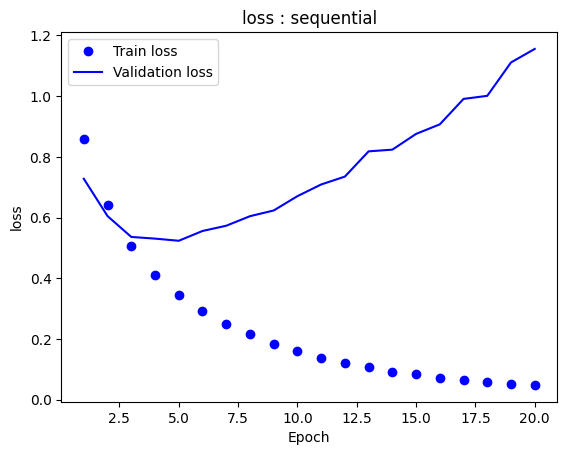

In [ ]:
base_history = deep_model(
    base_model,
    X_train_rest,
    y_train_rest,
    X_valid,
    y_valid
)

base_min = optimal_epoch(base_history)

eval_metric(base_model, base_history, 'loss')


## 17. Régularisation L2

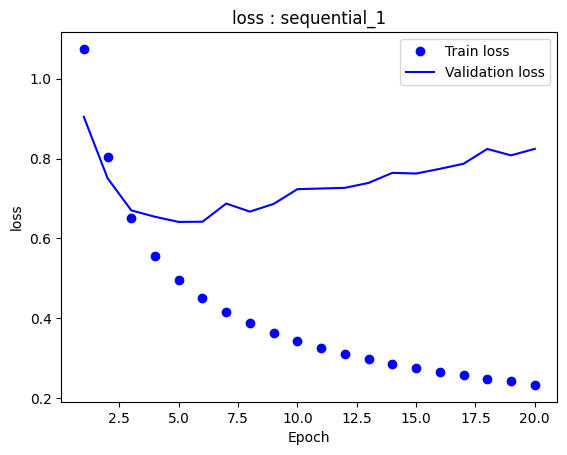

In [ ]:
reg_model = models.Sequential()

reg_model.add(
    layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(0.001),
        activation='relu',
        input_shape=(NB_WORDS,)
    )
)

reg_model.add(
    layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(0.001),
        activation='relu'
    )
)

reg_model.add(
    layers.Dense(
        3,
        activation='softmax'
    )
)

reg_model._name = 'L2_Regularisation'

reg_history = deep_model(
    reg_model,
    X_train_rest,
    y_train_rest,
    X_valid,
    y_valid
)

eval_metric(reg_model, reg_history, 'loss')


## 18. Régularisation L1

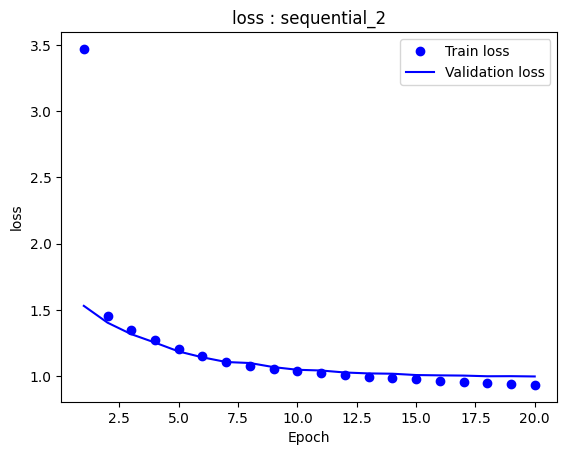

In [ ]:
reg_model_L1 = models.Sequential()

reg_model_L1.add(
    layers.Dense(
        64,
        kernel_regularizer=regularizers.l1(0.001),
        activation='relu',
        input_shape=(NB_WORDS,)
    )
)

reg_model_L1.add(
    layers.Dense(
        64,
        kernel_regularizer=regularizers.l1(0.001),
        activation='relu'
    )
)

reg_model_L1.add(
    layers.Dense(
        3,
        activation='softmax'
    )
)

reg_model_L1._name = 'L1_Regularisation'

reg_history_L1 = deep_model(
    reg_model_L1,
    X_train_rest,
    y_train_rest,
    X_valid,
    y_valid
)

eval_metric(reg_model_L1, reg_history_L1, 'loss')


## 19. Dropout

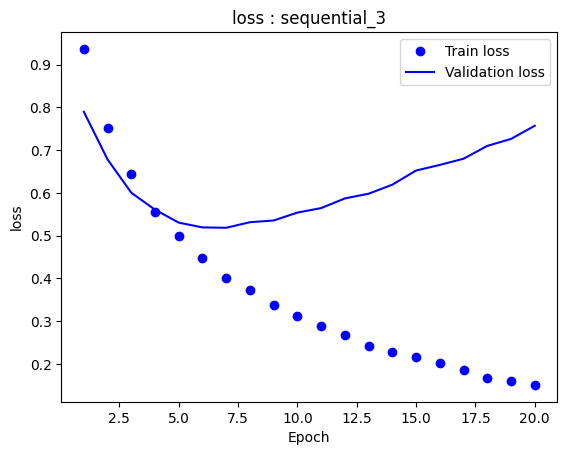

In [ ]:
drop_model = models.Sequential()

drop_model.add(
    layers.Dense(
        64,
        activation='relu',
        input_shape=(NB_WORDS,)
    )
)

drop_model.add(layers.Dropout(0.5))

drop_model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

drop_model.add(layers.Dropout(0.5))

drop_model.add(
    layers.Dense(
        3,
        activation='softmax'
    )
)

drop_model._name = 'Dropout'

drop_history = deep_model(
    drop_model,
    X_train_rest,
    y_train_rest,
    X_valid,
    y_valid
)

eval_metric(drop_model, drop_history, 'loss')
